<a href="https://colab.research.google.com/github/Akshra24/machine-learning-projects/blob/main/URL_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.utils import resample
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/benign_vs_defacement_urls.csv", encoding='latin-1', on_bad_lines='skip')

print("Dataset shape:", df.shape)
df = df[['url', 'type']]
print(df.head())

Dataset shape: (524621, 3)
                                                 url    type
0                mp3raid.com/music/krizz_kaliko.html  benign
1                    bopsecrets.org/rexroth/cr/1.htm  benign
2  http://buzzfil.net/m/show-art/ils-etaient-loin...  benign
3      espn.go.com/nba/player/_/id/3457/brandon-rush  benign
4     yourbittorrent.com/?q=anthony-hamilton-soulife  benign


/tmp/ipykernel_2316/3988895972.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/benign_vs_defacement_urls.csv", encoding='latin-1', on_bad_lines='skip')


In [ ]:
df.dropna(inplace=True)

# Rename columns if needed (adjust if your dataset differs)
df.columns = ['url', 'type']

# Convert labels
df['type'] = df['type'].map({'benign': 0, 'defacement': 1})


In [ ]:
df['url'] = df['url'].apply(
    lambda x: x if x.startswith('http') else 'http://' + x
)

In [ ]:
def get_features(url):
    try:
        parsed = urlparse(url)

        return {
            "url_length": len(url),
            "hostname_length": len(parsed.netloc) if parsed.netloc else 0,
            "dot_count": url.count('.'),
            "hyphen_count": url.count('-'),
            "at_count": url.count('@'),
            "question_count": url.count('?'),
            "percent_count": url.count('%'),
            "equal_count": url.count('='),
            "digit_count": sum(c.isdigit() for c in url),
            "slash_count": url.count('/'),
            "has_ip": 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
            "is_shortened": 1 if any(x in url for x in ["bit.ly", "tinyurl", "goo.gl"]) else 0
        }
    except:
        return {col: 0 for col in [
            "url_length","hostname_length","dot_count","hyphen_count",
            "at_count","question_count","percent_count","equal_count",
            "digit_count","slash_count","has_ip","is_shortened"
        ]}

In [ ]:
features = df['url'].apply(get_features)
X = pd.DataFrame(features.tolist())

In [ ]:
X = X.fillna(0)
print(X.isna().sum())

url_length         0
hostname_length    0
dot_count          0
hyphen_count       0
at_count           0
question_count     0
percent_count      0
equal_count        0
digit_count        0
slash_count        0
has_ip             0
is_shortened       0
dtype: int64


In [ ]:
X = features_df
y = df['type']

print("\nFeatures:\n", X.head())


Features:
    url_length  hostname_length  dot_count  hyphen_count  at_count  \
0          35                0          2             0         0   
1          31                0          2             0         0   
2         118               11          2            16         0   
3          45                0          2             1         0   
4          46                0          1             2         0   

   question_count  percent_count  equal_count  digit_count  slash_count  \
0               0              0            0            1            2   
1               0              0            0            1            3   
2               0              0            0            1            5   
3               0              0            0            4            6   
4               1              0            1            0            1   

   has_ip  is_shortened  
0       0             0  
1       0             0  
2       0             0  
3       0         

In [ ]:
df_combined = pd.concat([X, y], axis=1)

majority = df_combined[df_combined.type == 0]
minority = df_combined[df_combined.type == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

df_balanced = pd.concat([majority, minority_upsampled])

X = df_balanced.drop("type", axis=1)
y = df_balanced["type"]

print("\nBalanced counts:\n", y.value_counts())


Balanced counts:
 type
0.0    428103
1.0    428103
Name: count, dtype: int64


In [ ]:
# Remove infinity values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill ALL NaN
X = X.fillna(0)

# FINAL CHECK
print("NaN after cleaning:", X.isna().sum().sum())

NaN after cleaning: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

cm = confusion_matrix(y_test, y_pred)


Accuracy: 0.9717709440441014


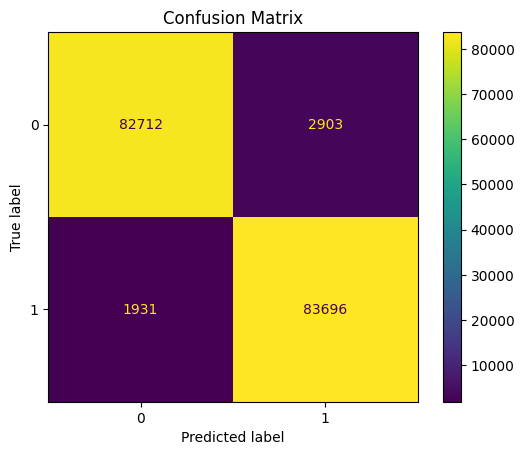

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

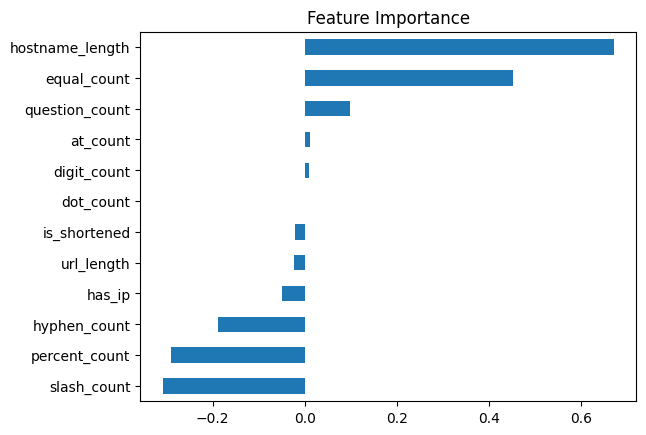

In [ ]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()